# **Ölçekleme, Yeniden Boyutlandırma, Enterpolasyon ve Kırpma**

**Bu derste şunları öğreneceğiz:**
1. Görüntüler nasıl yeniden boyutlandırılır ve ölçeklendirilir
2. Görüntü Piramitleri
3. Kırpma

### **Yeniden Boyutlandırma**
<img src="resizing.jpg" width="800">

Yeniden boyutlandırma, cv2.resize işlevini kullanarak yürüttüğümüz basit bir işlevdir, argümanları şunlardır:\
resized = cv2.resize(src, dsize, fx, fy, interpolation)\
dsize None ise çıktı görüntüsü fx & fy ölçeği kullanılarak ölçeklendirmenin bir fonksiyonu olarak hesaplanır

Parametreler
* src → Giriş görüntüsü (numpy array)
* dsize → Çıkış boyutu (width, height) formatında. Eğer (0,0) verilirse fx ve fy ile ölçekleme yapılır.
* fx → x ekseninde ölçekleme katsayısı (opsiyonel).
* fy → y ekseninde ölçekleme katsayısı (opsiyonel).
* interpolation → Yeniden boyutlandırma yöntemi (opsiyonel):
    * cv2.INTER_NEAREST → En yakın komşu (hızlı, düşük kalite)
    * cv2.INTER_LINEAR → Lineer interpolasyon (varsayılan)
    * cv2.INTER_CUBIC → Bicubic interpolasyon (daha kaliteli, yavaş)
    * cv2.INTER_LANCZOS4 → Daha kaliteli, yavaş

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

### **OpenCV'de Yeniden Ölçekleme Yöntemleri Türleri**
- **INTER_NEAREST** - en yakın komşu enterpolasyonu
- **INTER_LINEAR** - bir bilineer enterpolasyon (varsayılan olarak kullanılır)
- **INTER_AREA** - piksel alanı ilişkisini kullanarak yeniden örnekleme. Haresiz sonuçlar verdiği için görüntü küçültme için tercih edilen bir yöntem olabilir. Ancak görüntü yakınlaştırıldığında,INTER_NEAREST yöntemine benzer.
- **INTER_CUBIC** - 4×4 piksel komşuluğu üzerinde bir bikübik enterpolasyon
- **INTER_LANCZOS4** - 8×8 piksel komşuluğu üzerinde bir Lanczos enterpolasyonu


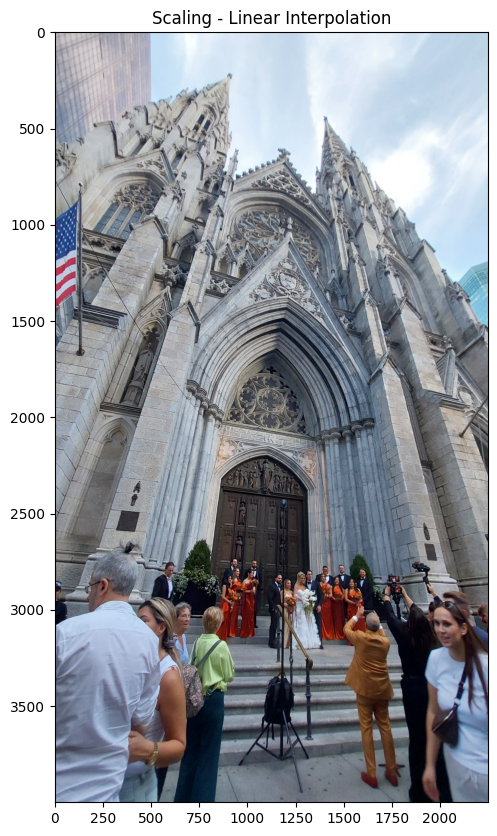

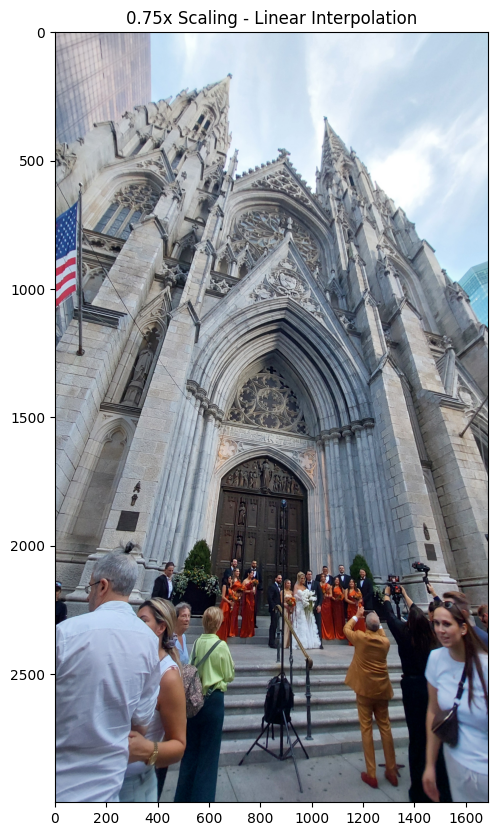

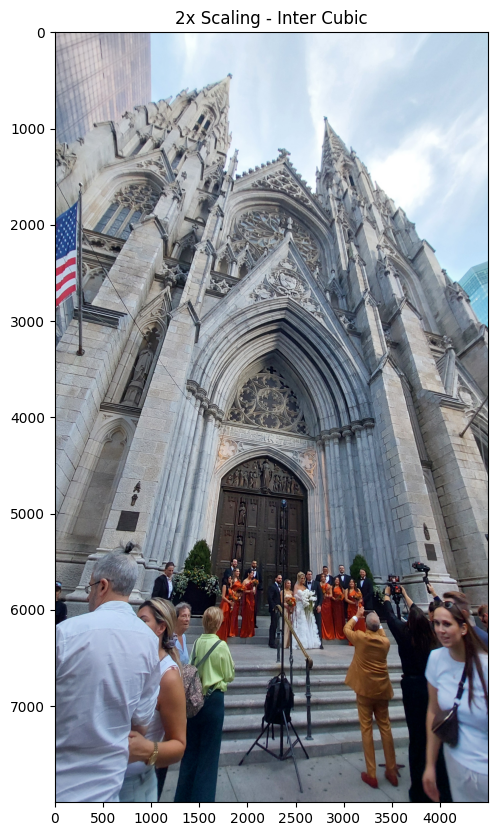

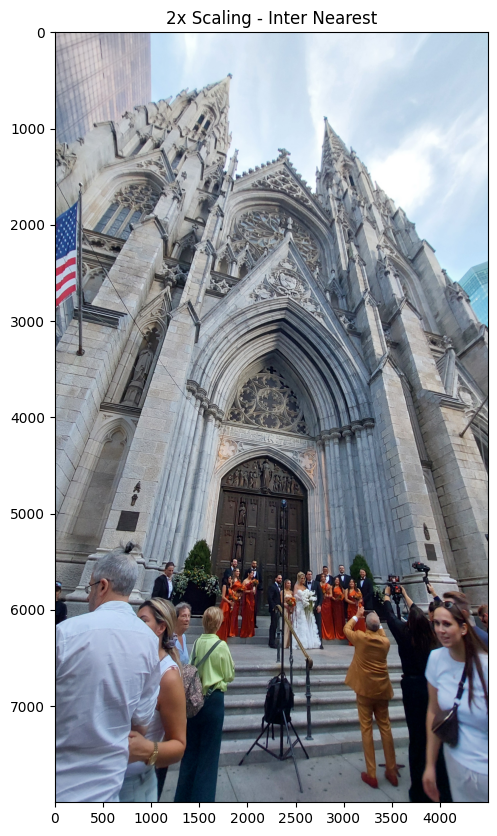

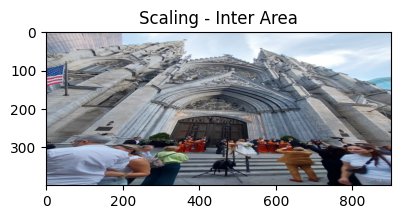

In [4]:
# Resmi yükleyelim
image = cv2.imread('../files/images/america3.jpg')
imshow("Scaling - Linear Interpolation", image)

# Herhangi bir enterpolasyon belirtilmezse cv.INTER_LINEAR varsayılan olarak kullanılır
# Resmimizi orijinal boyutunun 3/4'ü kadar yapalım
image_scaled = cv2.resize(image, None, fx=0.75, fy=0.75)
imshow("0.75x Scaling - Linear Interpolation", image_scaled)

# Resmimizin boyutunu iki katına çıkaralım
img_scaled2 = cv2.resize(image, None, fx=2, fy=2, interpolation = cv2.INTER_CUBIC)
imshow("2x Scaling - Inter Cubic", img_scaled2)

# En yakınlar arası enterpolasyonu kullanarak görüntümüzün boyutunu iki katına çıkaralım
img_scaled3 = cv2.resize(image, None, fx=2, fy=2, interpolation = cv2.INTER_NEAREST)
imshow("2x Scaling - Inter Nearest", img_scaled3)

# Tam boyutları ayarlayarak yeniden boyutlandırmayı çarpıtalım
img_scaled4 = cv2.resize(image, (900, 400), interpolation = cv2.INTER_AREA)
imshow("Scaling - Inter Area", img_scaled4)

## **Image Pyramids**

OpenCV’de bir görüntüyü Gaussian Pyramid (Gauss Piramidi) yöntemiyle yarı boyutuna küçültmek için kullanılır.
Kullanım: dst = cv2.pyrDown(src, dstsize, borderType)
Parametreler: 
* src → Giriş görüntüsü
* dstsize → Çıkış boyutu (width, height) formatında (opsiyonel). Normalde girişin yarısı alınır.
* borderType → Kenar doldurma yöntemi (genelde gerekmez).

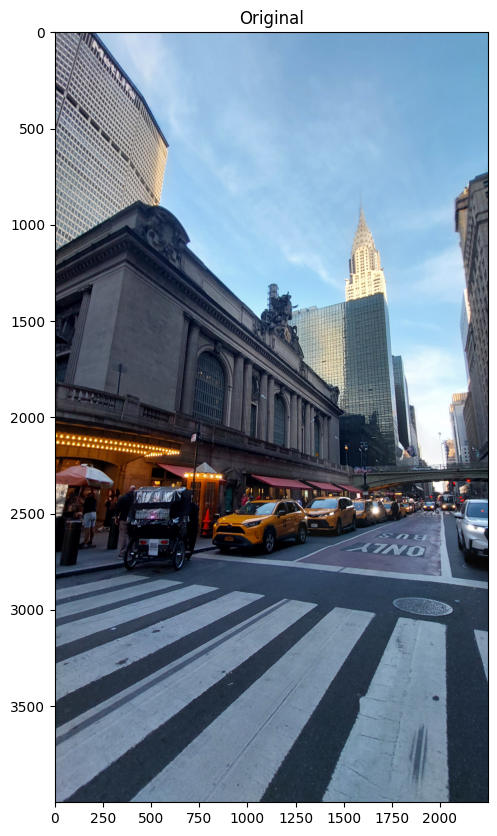

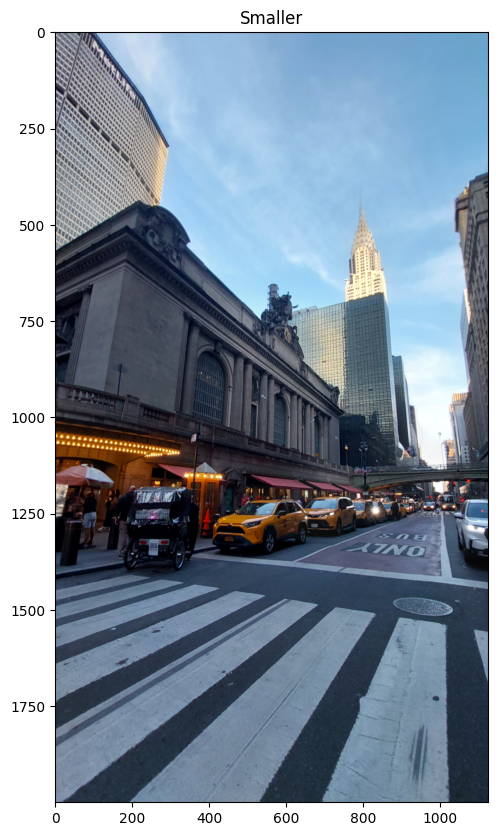

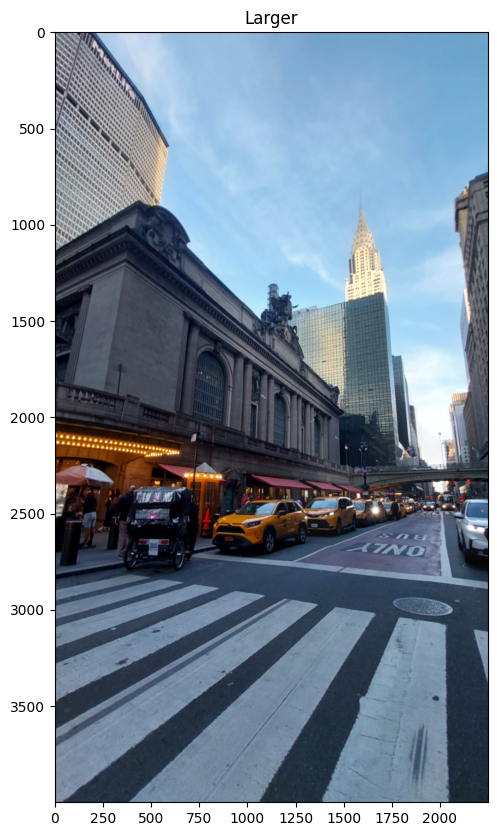

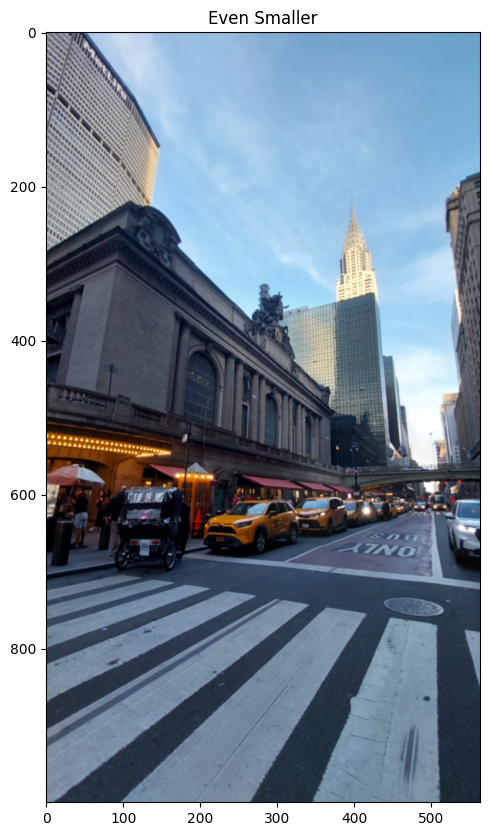

In [6]:
image = cv2.imread('../files/images/america4.jpg')

smaller = cv2.pyrDown(image)
larger = cv2.pyrUp(smaller)

imshow("Original", image)
imshow('Smaller', smaller)
imshow('Larger', larger)

even_smaller = cv2.pyrDown(smaller)
imshow('Even Smaller', even_smaller)

# **Kırpma**

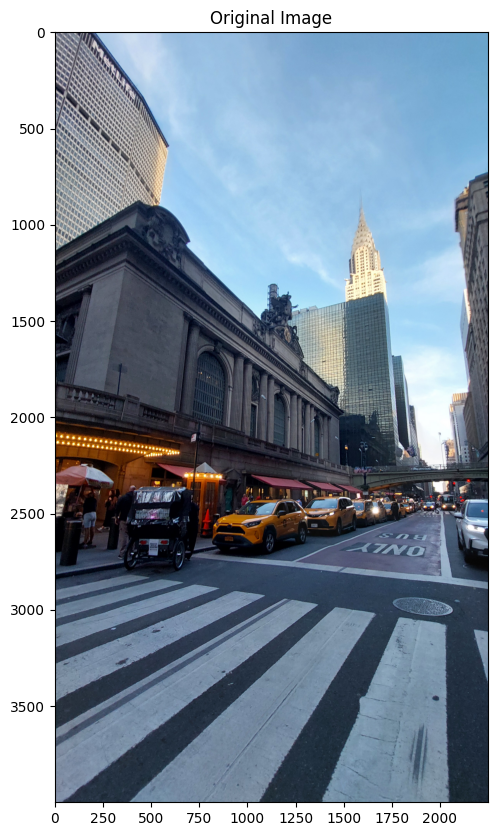

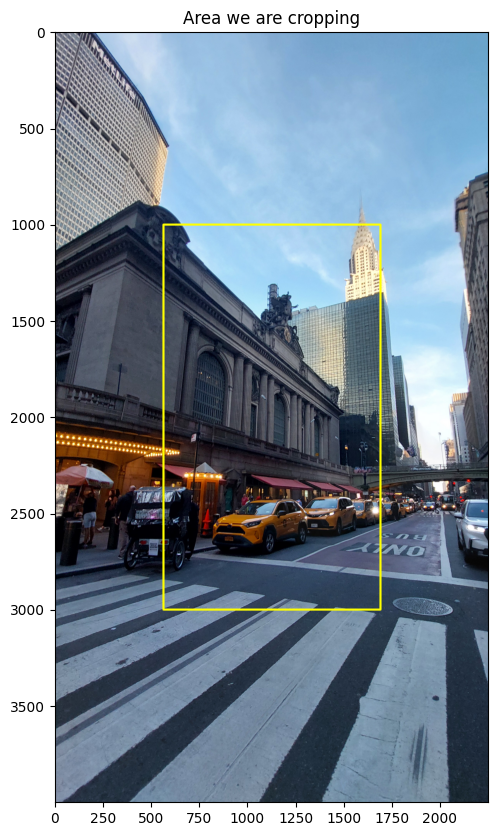

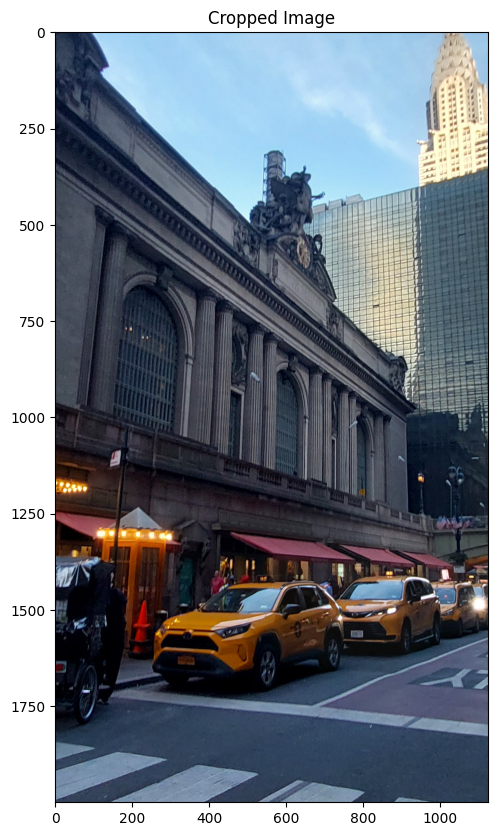

In [7]:
image = cv2.imread('../files/images/america4.jpg')

# Görüntü boyutlarımızı alalım
height, width = image.shape[:2]

# Başlangıç piksel koordinatlarını alalım (kırpma dikdörtgeninin sol üst kısmı)
# sol üstten (0,0) 1/4 aşağı olan x,y konumunu elde etmek için 0.25 kullanarak
start_row, start_col = int(height * .25), int(width * .25)

# Bitiş piksel koordinatlarını alalım (sağ alt)
end_row, end_col = int(height * .75), int(width * .75)

# İstediğimiz dikdörtgeni kırpmak için basitçe indekslemeyi kullanın
cropped = image[start_row:end_row , start_col:end_col]

imshow("Original Image", image)

# cv2.rectangle işlevi görüntümüzün üzerine bir dikdörtgen çizer (yerinde işlem)
copy = image.copy()
cv2.rectangle(copy, (start_col,start_row), (end_col,end_row), (0,255,255), 10)

imshow("Area we are cropping", copy)

imshow("Cropped Image", cropped) 